# EO Geometric Simulation Toolbox — Examples

This notebook demonstrates the main capabilities of the `EO_pixel_to_ground` toolbox.
Each case explores a different physical parameter to show its effect on the ground projection.

**Cases covered:**
1. Effect of orbital altitude
2. Effect of attitude (roll, pitch, combined, quarternion (TBD)) 
3. Effect of Earth model (sphere vs ellipsoid vs DEM (TBD))
4. Effect of instrument parameters (design parameters, MTF performance (TBD)
5. Pixel footprint deformation

> The toolbox functions are imported from `fonctions/`. Source code is not included in this repository.
> Full toolbox available as part of consulting engagements — [floragabriagues.github.io](https://floragabriagues.github.io)

In [1]:
from fonctions.LOS import project_pixel_center_to_ground, project_pixel_corners_to_ground
from fonctions.earth import dist_m_from_latlon
import fonctions.satellite as sat_module
import fonctions.display as display
import numpy as np
import matplotlib.pyplot as plt

# ── Style ──────────────────────────────────────────────────────────────
DARK_BG  = "#0d1117"
PANEL_BG = "#0d1520"
GRID_COL = "#1e2d3d"
TEXT_COL = "#e6edf3"
MUTED    = "#8b949e"
BLUE     = "#58a6ff"
ORANGE   = "#f78166"
GREEN    = "#3fb950"
YELLOW   = "#e3b341"
PURPLE   = "#bc8cff"

plt.rcParams.update({
    "font.family":     "monospace",
    "text.color":      TEXT_COL,
    "axes.labelcolor": TEXT_COL,
    "xtick.color":     MUTED,
    "ytick.color":     MUTED,
})

---
## Base configuration
Reference instrument and orbit used across all cases (overridden per case where needed).

In [2]:
# ── Pixel projected ID ───────────────────────────────────────────────────────────────
i, j = 512, 512 # to compute relative location regarding to the central pixel/LOS origin

# ── Instrument ───────────────────────────────────────────────────────────────────────
instrument = {
    "f"  : 1.5,       # focal length (m)
    "px" : 3.6e-6,    # pixel pitch along i (m)
    "py" : 3.6e-6,    # pixel pitch along j (m)
    "i0" : 512,       # central pixel row
    "j0" : 512,       # central pixel column
    "boresight": {"bx": 0.0, "by": 0.0, "bz": 0.0}  # instrument internal misalignement in Rinst (rad)
}

# ── Instrument–platform interface ────────────────────────────────────────────────────
IF_misalignement = {"mx": 0.0, "my": 0.0, "mz": 0.0}  # interface misalignement in Rsat (rad)

# ── Orbit configuration ──────────────────────────────────────────────────────────────
def config_orbit_attitude(altitude_m, roll=0, pitch=0, yaw=0,
                   inc_deg=98, theta_deg=45,
                   t_utc=np.datetime64("2025-05-01T14:00:00")):
    """
    Configure orbit and attitude parameters of the satellite.

    Parameters
    ----------
    altitude_m : float — orbital altitude in metres
    roll, pitch, yaw : float — attitude angles in degrees Rsat -> LVLH
    inc_deg : float — orbital inclination in degrees
    theta_deg : float — true anomaly in degrees
    t_utc : np.datetime64 — UTC time of observation
    """
    inc   = np.deg2rad(inc_deg)
    theta = np.deg2rad(theta_deg)
    R_earth = 6371000  # m
    x_sat = altitude_m + R_earth

    position_ECI = np.array([
        x_sat * np.cos(theta),
        x_sat * np.sin(theta) * np.cos(inc),
        x_sat * np.sin(theta) * np.sin(inc)
    ])
    velocity_ECI = sat_module.fct_vsat(altitude_m / 1e3) * np.array([
        -np.sin(theta),
         np.cos(theta) * np.cos(inc),
         np.cos(theta) * np.sin(inc)
    ])
    return {
        "position_sat_ECI": position_ECI,
        "velocity_sat_ECI": velocity_ECI,
        "t_utc"           : t_utc,
        "att_quat_RPY"    : [roll, pitch, yaw]
    }

---
## Case 1 — Effect of orbital altitude

Same instrument, same attitude (nadir), same orbital parameters.  
Varying altitude: 400 km, 500 km, 600 km.  

Expected: higher altitude → larger ground displacement per degree of roll.

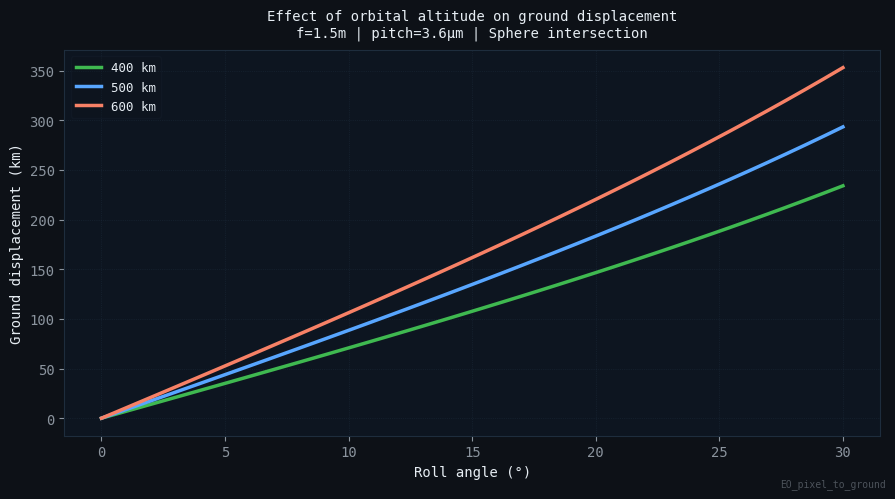

In [3]:
plt.close('all')

altitudes = {
    "400 km" : (400000, GREEN),
    "500 km" : (500000, BLUE),
    "600 km" : (600000, ORANGE),
}

roll_range = np.linspace(0, 30, 40) # 40 points between 0 and 30 degrees

fig, ax = plt.subplots(figsize=(9, 5), facecolor=DARK_BG)
ax.set_facecolor(PANEL_BG)

for label, (alt, color) in altitudes.items():
    displacements = []
    sat_nadir = config_orbit_attitude(alt, roll=0)
    
    # call to the toolbox function to project the pixel center to the ground -> NADIR
    lat0, lon0 = project_pixel_center_to_ground(i, j, instrument, IF_misalignement, sat_nadir, att_mode="RPY", earth_model="sphere", plot=False)
    for roll in roll_range:
        sat = config_orbit_attitude(alt, roll=roll)
        
        # call to the toolbox function to project the pixel center to the ground -> differents rolls
        lat, lon = project_pixel_center_to_ground(i, j, instrument, IF_misalignement, sat, att_mode="RPY", earth_model="sphere", plot=False)
        displacements.append(dist_m_from_latlon(lat0, lon0, lat, lon) / 1e3)  # computed with pymap3d.geodetic2aer

    ax.plot(roll_range, displacements, color=color, lw=2.5, label=label)

ax.set_xlabel("Roll angle (°)", fontsize=10)
ax.set_ylabel("Ground displacement (km)", fontsize=10)
ax.set_title(f"Effect of orbital altitude on ground displacement\n" f"f={instrument['f']}m | pitch={instrument['px']*1e6:.1f}µm | Sphere intersection", fontsize=10, color=TEXT_COL, pad=10)
ax.legend(fontsize=9, framealpha=0.2, facecolor=DARK_BG, edgecolor=GRID_COL, labelcolor=TEXT_COL)
ax.grid(True, color=GRID_COL, linewidth=0.5, linestyle=":", alpha=0.8)
for spine in ax.spines.values():
    spine.set_edgecolor(GRID_COL)
fig.text(0.99, 0.01, "EO_pixel_to_ground", fontsize=7, color=MUTED, ha="right", va="bottom", alpha=0.5)
plt.tight_layout()
plt.show()

---
## Case 2 — Effect of attitude

Fixed altitude (500 km), fixed instrument.  
5 attitude cases: nadir, roll 10°, roll 20°, pitch 10°, pitch 20°.  
Pitch cases are aligned with satellite ground track.
Rolls cases are deported.

Saved: case2_attitude.png


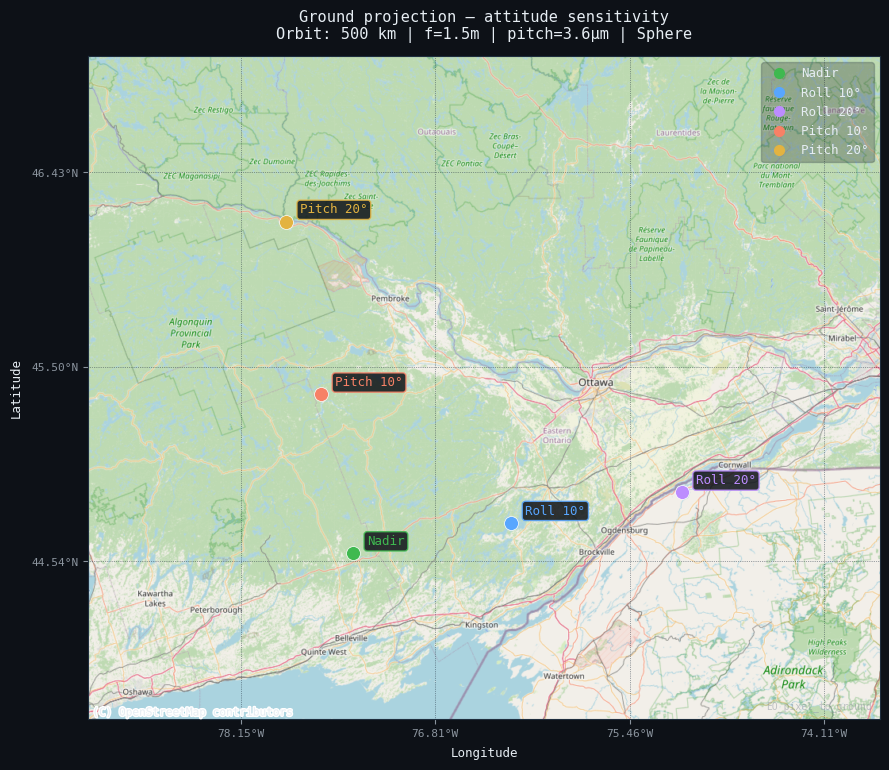

In [4]:
plt.close('all')

attitudes = [
    ([0,  0, 0], "Nadir",    GREEN),
    ([10, 0, 0], "Roll 10°", BLUE),
    ([20, 0, 0], "Roll 20°", PURPLE),
    ([0, 10, 0], "Pitch 10°",ORANGE),
    ([0, 20, 0], "Pitch 20°",YELLOW),
]

lats, lons, labels, colors = [], [], [], []
for rpy, label, color in attitudes:
    sat = config_orbit_attitude(500_000, roll=rpy[0], pitch=rpy[1], yaw=rpy[2])
    lat, lon = project_pixel_center_to_ground(
        i, j, instrument, IF_misalignement, sat,
        att_mode="RPY", earth_model="sphere", plot=False
    )
    lats.append(lat)
    lons.append(lon)
    labels.append(label)
    colors.append(color)

display.display_latlon_basemap(
    lats=lats, lons=lons,
    point_labels=labels,
    point_colors=colors,
    connect_points=False,
    title="Ground projection — attitude sensitivity",
    subtitle=f"Orbit: 500 km | f={instrument['f']}m | pitch={instrument['px']*1e6:.1f}µm | Sphere",
    save_path="case2_attitude.png"
)

---
## Case 3 — Effect of Earth model regarding to latitude
  
Comparing sphere vs WGS84 ellipsoid intersection models at different latitude for a fixed attitude.  

The sphere R=6371 km is the **volumetric mean radius** of WGS84 — it is closest to the ellipsoid
around ~45° latitude, which is why Mid-lat shows the smallest error.

- **Equator**: WGS84 is ~7 km *larger* than the sphere → the ellipsoid intersects further out → positive error
- **High-lat (75°)**: WGS84 is ~14 km *smaller* than the sphere → the ellipsoid intersects closer in → error grows in the opposite direction
- **Mid-lat (45°)**: the two effects partially cancel → minimum error

The error magnitude varies with latitude — the sphere overestimates the Earth radius at the equator and underestimates it near the poles, but dist_m_from_latlon returns absolute distances so the sign is not visible here.

At 30° roll, the sphere introduces up to **~8 km** of geolocation error at high latitudes.
This is non-negligible for any mission requiring sub-km absolute geolocation accuracy.

Equator  @ 30° roll : 4567.2 m
Mid-lat  @ 30° roll : 2446.3 m
High-lat @ 30° roll : 8425.7 m


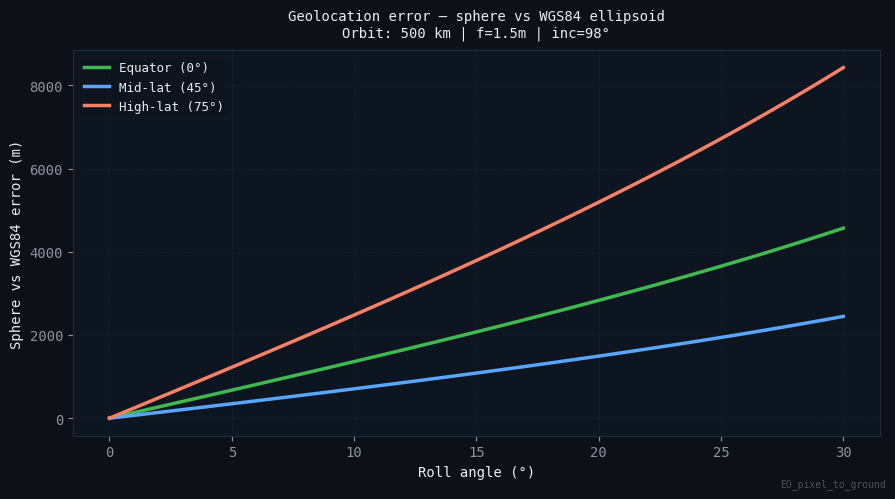

In [5]:
plt.close('all')

roll_range  = np.linspace(0, 30, 40)
latitudes   = [
    (0,  "Equator (0°)",   GREEN),
    (45, "Mid-lat (45°)",  BLUE),
    (75, "High-lat (75°)", ORANGE),
]

def theta_for_latitude(target_lat_deg, inc_deg=98):
    inc = np.deg2rad(inc_deg)
    target = np.deg2rad(target_lat_deg) # sin(lat) = sin(theta) * sin(inc)
    return np.rad2deg(np.arcsin(np.sin(target) / np.sin(inc)))

fig, ax = plt.subplots(figsize=(9, 5), facecolor=DARK_BG)
ax.set_facecolor(PANEL_BG)
ax.grid(True, color=GRID_COL, linewidth=0.5, linestyle=":", alpha=0.8)
for spine in ax.spines.values():
    spine.set_edgecolor(GRID_COL)

results_diff = {}
for lat_deg, label, color in latitudes:
    theta = theta_for_latitude(lat_deg)

    diff_m = []
    for roll in roll_range:
        sat = config_orbit_attitude(500000, roll=roll, theta_deg=theta)

        lat_s, lon_s = project_pixel_center_to_ground(
            i, j, instrument, IF_misalignement, sat,
            att_mode="RPY", earth_model="sphere", plot=False
        )
        lat_e, lon_e = project_pixel_center_to_ground(
            i, j, instrument, IF_misalignement, sat,
            att_mode="RPY", earth_model="ellipsoid", plot=False
        )
        diff_m.append(dist_m_from_latlon(lat_s, lon_s, lat_e, lon_e))

    results_diff[lat_deg] = np.array(diff_m)
    ax.plot(roll_range, results_diff[lat_deg], color=color, lw=2.5, label=label)

print(f"Equator  @ 30° roll : {results_diff[0][-1]:.1f} m")
print(f"Mid-lat  @ 30° roll : {results_diff[45][-1]:.1f} m")
print(f"High-lat @ 30° roll : {results_diff[75][-1]:.1f} m")

ax.set_xlabel("Roll angle (°)", fontsize=10)
ax.set_ylabel("Sphere vs WGS84 error (m)", fontsize=10)
ax.set_title(
    "Geolocation error — sphere vs WGS84 ellipsoid\n"
    f"Orbit: 500 km | f={instrument['f']}m | inc=98°",
    fontsize=10, color=TEXT_COL, pad=10
)
ax.legend(fontsize=9, framealpha=0.2, facecolor=DARK_BG,
          edgecolor=GRID_COL, labelcolor=TEXT_COL)
fig.text(0.99, 0.01, "EO_pixel_to_ground", fontsize=7,
         color=MUTED, ha="right", va="bottom", alpha=0.5)
plt.tight_layout()
plt.show()

---
## Case 4 — Effect of instrument parameters

Fixed orbit (500 km, nadir), fixed attitude.  
Varying focal length and pixel pitch to show GSD and footprint size sensitivity.

| Instrument | Focal length | Pixel pitch | GSD @ 500 km |
|---|---|---|---|
| Short focal / large pitch | 0.5 m | 10 µm | ~10 m |
| Reference | 1.5 m | 3.6 µm | ~1.2 m |
| Long focal / small pitch | 3.0 m | 2.0 µm | ~0.33 m |

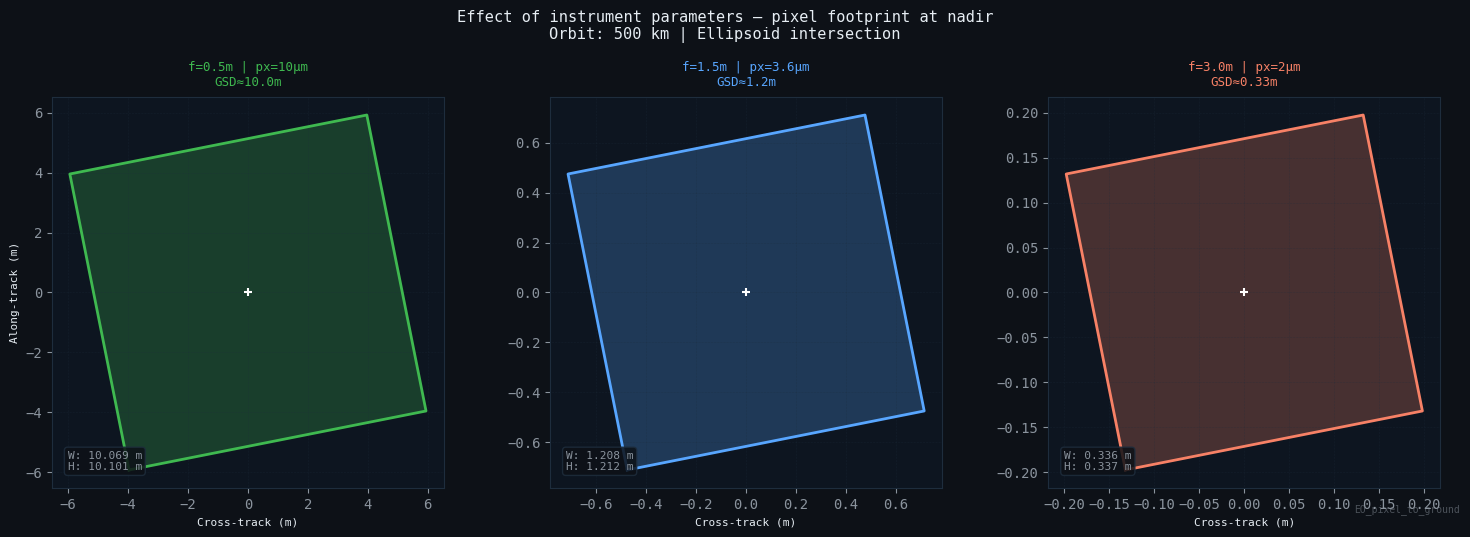

In [6]:
plt.close('all')

def config_instrument(f, px, py=None, i0=512, j0=512):
    if py is None:
        py = px
    return {
        "f": f, "px": px, "py": py,
        "i0": i0, "j0": j0,
        "boresight": {"bx": 0.0, "by": 0.0, "bz": 0.0}
    }

instruments = {
    f"f=0.5m | px=10µm\nGSD≈{500000*10e-6/0.5:.1f}m" : (config_instrument(0.5, 10e-6),  GREEN),
    f"f=1.5m | px=3.6µm\nGSD≈{500000*3.6e-6/1.5:.1f}m": (config_instrument(1.5, 3.6e-6), BLUE),
    f"f=3.0m | px=2µm\nGSD≈{500000*2e-6/3.0:.2f}m"  : (config_instrument(3.0, 2e-6),   ORANGE),
}

sat_nadir = config_orbit_attitude(500000, roll=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor=DARK_BG)
fig.suptitle("Effect of instrument parameters — pixel footprint at nadir\n" "Orbit: 500 km | Ellipsoid intersection", fontsize=11, color=TEXT_COL, y=1.02)

for ax, (label, (instr, color)) in zip(axes, instruments.items()):
    ax.set_facecolor(PANEL_BG)

    # project pixel center and corners to ground (WGS84 ellipsoid)
    lats_c, lons_c = project_pixel_corners_to_ground(i, j, instr, IF_misalignement, sat_nadir, att_mode="RPY", earth_model='ellipsoid')
    lat_ctr, lon_ctr = project_pixel_center_to_ground(i, j, instr, IF_misalignement, sat_nadir, att_mode="RPY", earth_model="ellipsoid", plot=False)

    # convert lat/lon corners to local metric offsets centered on pixel center
    # np.sign preserves direction (left/right, fore/aft) since dist_m_from_latlon is always positive
    lons_m  = [np.sign(lo - lon_ctr) * dist_m_from_latlon(lat_ctr, lon_ctr, lat_ctr, lo) for lo in lons_c]
    lats_m  = [np.sign(la - lat_ctr) * dist_m_from_latlon(lat_ctr, lon_ctr, la, lon_ctr) for la in lats_c]

    # close the polygon for plotting
    lons_mc = lons_m + [lons_m[0]]
    lats_mc = lats_m + [lats_m[0]]

    ax.fill(lons_mc, lats_mc, color=color, alpha=0.25)
    ax.plot(lons_mc, lats_mc, color=color, linewidth=2)
    ax.scatter(0, 0, color="white", s=30, zorder=5, marker="+")  # pixel center

    # footprint dimensions: width (cross-track) and height (along-track)
    width_m  = np.sqrt((lons_m[1]-lons_m[0])**2 + (lats_m[1]-lats_m[0])**2)
    height_m = np.sqrt((lons_m[3]-lons_m[0])**2 + (lats_m[3]-lats_m[0])**2)

    ax.text(0.04, 0.04, f"W: {width_m:.3f} m\nH: {height_m:.3f} m", transform=ax.transAxes, fontsize=8, color=MUTED, verticalalignment="bottom", bbox=dict(boxstyle="round,pad=0.3", facecolor=DARK_BG, edgecolor=GRID_COL, alpha=0.85))
    ax.set_aspect("equal")
    ax.grid(True, color=GRID_COL, linewidth=0.4, linestyle=":", alpha=0.7)
    ax.set_xlabel("Cross-track (m)", fontsize=8)
    ax.set_title(label, fontsize=9, color=color, pad=8)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COL)

axes[0].set_ylabel("Along-track (m)", fontsize=8)
fig.text(0.99, 0.01, "EO_pixel_to_ground", fontsize=7, color=MUTED, ha="right", va="bottom", alpha=0.5)
plt.tight_layout()
plt.show()

---
## Case 5 — Pixel footprint deformation

Fixed instrument and orbit (500 km).  
4 attitude cases: nadir, roll 10°, pitch 10°, combined roll+pitch 10°.  

Shows how a square pixel becomes geometrically distorted as a function of pointing angle.

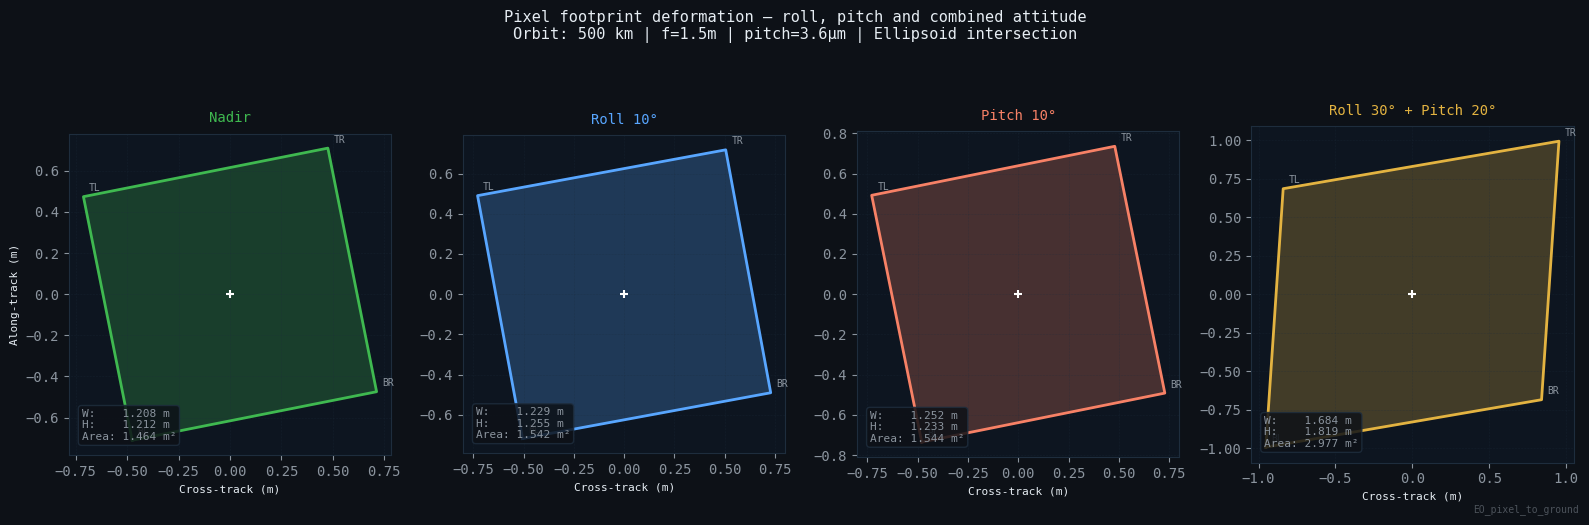

In [7]:
plt.close('all')

attitudes = [
    ([0,   0,  0], "Nadir",                GREEN),
    ([10,  0,  0], "Roll 10°",             BLUE),
    ([0,  10,  0], "Pitch 10°",            ORANGE),
    ([30, 20,  0], "Roll 30° + Pitch 20°", YELLOW),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5), facecolor=DARK_BG)
fig.suptitle(f"Pixel footprint deformation — roll, pitch and combined attitude\n" f"Orbit: 500 km | f={instrument['f']}m | pitch={instrument['px']*1e6:.1f}µm | Ellipsoid intersection", fontsize=11, color=TEXT_COL, y=1.02)

for ax, (rpy, label, color) in zip(axes, attitudes):
    ax.set_facecolor(PANEL_BG)

    sat = config_orbit_attitude(500000, roll=rpy[0], pitch=rpy[1], yaw=rpy[2])

    lats_c, lons_c = project_pixel_corners_to_ground(i, j, instrument, IF_misalignement, sat, att_mode="RPY", earth_model='ellipsoid')
    lat_ctr, lon_ctr = project_pixel_center_to_ground(i, j, instrument, IF_misalignement, sat, att_mode="RPY", earth_model="ellipsoid", plot=False)

    # convert lat/lon corners to local metric offsets centered on pixel center
    # np.sign preserves direction (left/right, fore/aft) since dist_m_from_latlon is always positive
    lons_m  = [np.sign(lo - lon_ctr) * dist_m_from_latlon(lat_ctr, lon_ctr, lat_ctr, lo) for lo in lons_c]
    lats_m  = [np.sign(la - lat_ctr) * dist_m_from_latlon(lat_ctr, lon_ctr, la, lon_ctr) for la in lats_c]

    # close the polygon for plotting
    lons_mc = lons_m + [lons_m[0]]
    lats_mc = lats_m + [lats_m[0]]

    width_m  = np.sqrt((lons_m[1]-lons_m[0])**2 + (lats_m[1]-lats_m[0])**2)
    height_m = np.sqrt((lons_m[3]-lons_m[0])**2 + (lats_m[3]-lats_m[0])**2)
    area_m2  = 0.5 * abs(sum(lons_m[k]*lats_m[(k+1)%4] - lons_m[(k+1)%4]*lats_m[k] for k in range(4)))
    
    ax.fill(lons_mc, lats_mc, color=color, alpha=0.25)
    ax.plot(lons_mc, lats_mc, color=color, linewidth=2)

    for lo, la, cl in zip(lons_m, lats_m, ["BL", "TL", "TR", "BR"]):
        ax.annotate(cl, (lo, la), fontsize=7, color=MUTED, textcoords="offset points", xytext=(4, 4))

    ax.scatter(0, 0, color="white", s=30, zorder=5, marker="+")
    ax.text(0.04, 0.04, f"W:    {width_m:.3f} m\nH:    {height_m:.3f} m\nArea: {area_m2:.3f} m²", transform=ax.transAxes, fontsize=8, color=MUTED, verticalalignment="bottom", bbox=dict(boxstyle="round,pad=0.3", facecolor=DARK_BG, edgecolor=GRID_COL, alpha=0.85))
    ax.set_aspect("equal")
    ax.grid(True, color=GRID_COL, linewidth=0.4, linestyle=":", alpha=0.7)
    ax.set_xlabel("Cross-track (m)", fontsize=8)
    ax.set_title(label, fontsize=10, color=color, pad=8)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COL)

axes[0].set_ylabel("Along-track (m)", fontsize=8)
fig.text(0.99, 0.01, "EO_pixel_to_ground", fontsize=7,
         color=MUTED, ha="right", va="bottom", alpha=0.5)
plt.tight_layout()
plt.show()

---
## Case 6 — Accessible ground zone


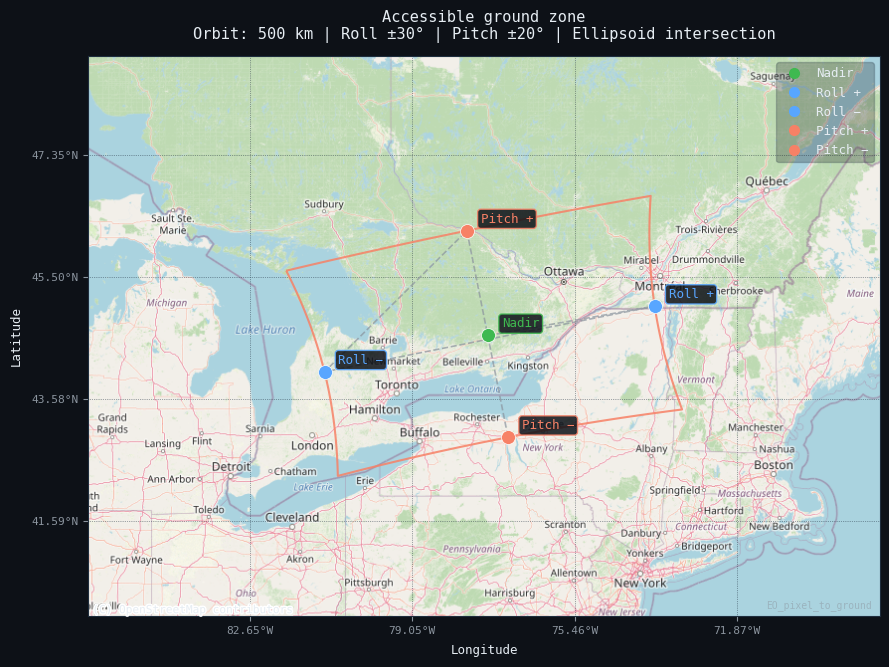

In [8]:
plt.close('all')

roll_max  = 30   # degrees
pitch_max = 20   # degrees
n_points  = 50   # interpolation points per side


def sweep_border(roll_values, pitch_values):
    lats, lons = [], []
    for r, p in zip(roll_values, pitch_values):
        sat_t = config_orbit_attitude(500_000, roll=r, pitch=p, yaw=0)
        lat, lon = project_pixel_center_to_ground(
            i, j, instrument, IF_misalignement, sat_t,
            att_mode="RPY", earth_model="ellipsoid", plot=False
        )
        lats.append(lat)
        lons.append(lon)
    return lats, lons

lin  = np.linspace
zero = np.zeros(n_points)

# 4 borders of the rectangle in attitude space
borders = [
    (lin(-roll_max,  roll_max, n_points), zero - pitch_max),  # bottom
    (zero + roll_max,  lin(-pitch_max, pitch_max, n_points)), # right
    (lin( roll_max, -roll_max, n_points), zero + pitch_max),  # top
    (zero - roll_max,  lin( pitch_max,-pitch_max, n_points)), # left
]

border_lats, border_lons = [], []
for roll_vals, pitch_vals in borders:
    lats, lons = sweep_border(roll_vals, pitch_vals)
    border_lats.extend(lats)
    border_lons.extend(lons)

# close the polygon
border_lats.append(border_lats[0])
border_lons.append(border_lons[0])

sat_nadir = config_orbit_attitude(500_000, roll=0, pitch=0, yaw=0)
lat_nadir, lon_nadir = project_pixel_center_to_ground(i, j, instrument, IF_misalignement, sat_nadir, att_mode="RPY", earth_model="ellipsoid", plot=False)

# --- Roll +/- indicators ---
sat_roll_pos = config_orbit_attitude(500000, roll=+roll_max, pitch=0, yaw=0)
lat_rp, lon_rp = project_pixel_center_to_ground(i, j, instrument, IF_misalignement, sat_roll_pos, att_mode="RPY", earth_model="ellipsoid", plot=False)

sat_roll_neg = config_orbit_attitude(500000, roll=-roll_max, pitch=0, yaw=0)
lat_rn, lon_rn = project_pixel_center_to_ground(i, j, instrument, IF_misalignement, sat_roll_neg, att_mode="RPY", earth_model="ellipsoid", plot=False)

sat_pitch_pos = config_orbit_attitude(500000, roll=0, pitch=+pitch_max, yaw=0)
lat_pp, lon_pp = project_pixel_center_to_ground(i, j, instrument, IF_misalignement, sat_pitch_pos, att_mode="RPY", earth_model="ellipsoid", plot=False)

sat_pitch_neg = config_orbit_attitude(500000, roll=0, pitch=-pitch_max, yaw=0)
lat_pn, lon_pn = project_pixel_center_to_ground(i, j, instrument, IF_misalignement, sat_pitch_neg, att_mode="RPY", earth_model="ellipsoid", plot=False)

display.display_latlon_basemap(
    lats=[lat_nadir, lat_rp, lat_rn, lat_pp, lat_pn],
    lons=[lon_nadir, lon_rp, lon_rn, lon_pp, lon_pn],
    point_labels=["Nadir", "Roll +", "Roll −", "Pitch +", "Pitch −"],
    point_colors=[GREEN, BLUE, BLUE, ORANGE, ORANGE],
    track_lats=border_lats,
    track_lons=border_lons,
    track_color="#f78166",
    track_label=f"Roll ±{roll_max}° | Pitch ±{pitch_max}°",
    title="Accessible ground zone",
    subtitle=f"Orbit: 500 km | Roll ±{roll_max}° | Pitch ±{pitch_max}° | Ellipsoid intersection"
)

---
## Summary

| Case | Parameter varied | Key result |
|---|---|---|
| 1 | Orbital altitude | Higher altitude → larger displacement per degree of roll |
| 2 | Attitude (RPY) | Roll → cross-track, pitch → along-track |
| 3 | Earth model | Sphere vs WGS84 → measurable geolocation error at high roll angles |
| 4 | Instrument (f, pitch) | GSD scales linearly with altitude/focal ratio |
| 5 | Attitude + footprint | Combined roll+pitch → displaced and deformed pixel |
| 6 | Agility envelope | Roll/pitch sweep → accessible ground zone |

---

> Full toolbox available as part of consulting engagements.  
> → [floragabriagues.github.io](https://floragabriagues.github.io)